In [1]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

# BoW Method

In [2]:
model_bow_logreg = joblib.load('models/review/bow_logreg_review_rec.joblib')
model_bow_rfc = joblib.load('models/review/bow_rfc_review_rec.joblib')
model_bow_linreg = joblib.load('models/review/bow_linreg_review_rat.joblib')
model_bow_rfr = joblib.load('models/review/bow_rfr_review_rat.joblib')

In [3]:
bow_val = pd.read_csv('train_test_val/val/val_bow.csv')

In [4]:
bow_val.head()

,Rating,Recommended,full_review,clean_text
0,5,1,Roll-ups that are versitile These are magnific...,rollup versitile magnificent trouser size typi...
1,4,1,"Swim Runs small in the chest, so don't order i...",swim run small chest not order large cheste cute
2,5,1,"Soft, stylish sweater clothe! love it! This is...",soft stylish sweater clothe love simply fabulo...
3,5,1,Magnificent present I ordered christmas presen...,magnificent present order christmas present on...
4,2,0,Flimsy I loved the cut and the stretch in the ...,flimsy love cut stretch material comfortable f...


In [5]:
tfidf = joblib.load('models/vectorization/vectorization_bow.joblib')

In [6]:
X_vec = tfidf.transform(bow_val['clean_text'])
X_vec.shape

(2718, 5000)

In [7]:
y_rec = bow_val['Recommended']
y_rec.shape

(2718,)

In [8]:
y_rat = bow_val['Rating']
y_rat.shape

(2718,)

In [9]:
y_pred_logreg = model_bow_logreg.predict(X_vec)

In [10]:
y_pred_rfc = model_bow_rfc.predict(X_vec)

In [11]:
y_pred_linreg = model_bow_linreg.predict(X_vec)

In [12]:
y_pred_rfr = model_bow_rfr.predict(X_vec)

In [13]:
print('Logistic Regression\n')
print(classification_report(y_rec, y_pred_logreg))

Logistic Regression

              precision    recall  f1-score   support

           0       0.64      0.83      0.72       525
           1       0.96      0.89      0.92      2193

    accuracy                           0.88      2718
   macro avg       0.80      0.86      0.82      2718
weighted avg       0.89      0.88      0.88      2718



In [14]:
print('Random Forest Classifier\n')
print(classification_report(y_rec, y_pred_rfc))

Random Forest Classifier

              precision    recall  f1-score   support

           0       0.85      0.29      0.44       525
           1       0.85      0.99      0.92      2193

    accuracy                           0.85      2718
   macro avg       0.85      0.64      0.68      2718
weighted avg       0.85      0.85      0.82      2718



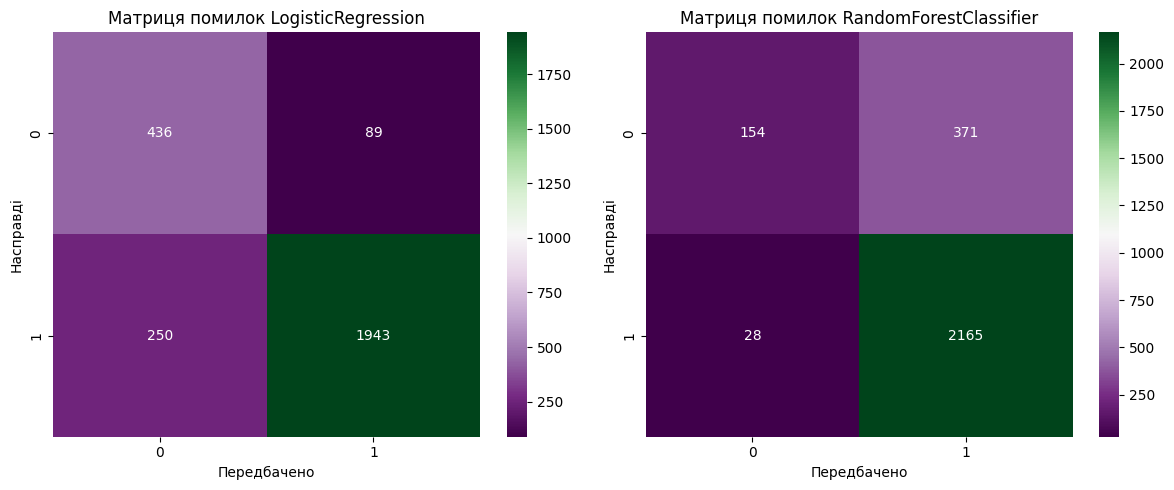

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

cm = confusion_matrix(y_rec, y_pred_logreg)
sns.heatmap(cm, annot=True, fmt='d', cmap='PRGn')
plt.xlabel('Передбачено')
plt.ylabel('Насправді')
plt.title('Матриця помилок LogisticRegression')

plt.subplot(1, 2, 2)

cm = confusion_matrix(y_rec, y_pred_rfc)
sns.heatmap(cm, annot=True, fmt='d', cmap='PRGn')
plt.xlabel('Передбачено')
plt.ylabel('Насправді')
plt.title('Матриця помилок RandomForestClassifier')

plt.tight_layout()
plt.show()

Маємо цікаве порівняння.  
Для різних бізнес задач, можна використовувати різні моделі.  
Логістична регресія дала баланс між precision and recall,  
гарно визначивши негативні відгуки.  

Random Forest натомість, навіть з балансуванням класів, краще визначає саме позитивні відгуки.  

Отже, залежить від поставлених задач.  
Чи ми бажаємо бачити тільки позитивні відгуки,  
чи нам потрібні негативні для роботи з продуктом/клієнтами.

In [16]:
linreg = np.round(np.clip(y_pred_linreg, 1, 5))
rfr = np.round(np.clip(y_pred_rfr, 1, 5))

In [17]:
print(f'LinReg MAE: {mean_absolute_error(y_rat, linreg):.2f}'
      f'\nRandomForest MAE: {mean_absolute_error(y_rat, rfr):.2f}')

LinReg MAE: 0.62
RandomForest MAE: 0.63


In [18]:
print(f'LinReg R2: {r2_score(y_rat, linreg):.2f}'
      f'\nRandomForest R2: {r2_score(y_rat, rfr):.2f}')

LinReg R2: 0.26
RandomForest R2: 0.28


Для визначення рейтингу скористалася регресивними моделями:  
 * Logistic Regression  
 * Random Forest Regressor

Отримала цікаві результати.  
Обидві моделі гарно розібралися із загальним 'настроєм' оцінок.  
Помиляються тільки на 0.62 та 0.63 бали.

А от оцінка R2 свідчить про непослідовність покупців,  
які можуть писати супер відгук і ставити низьку оцінку,  
або використовувати схожі слова для різних оцінок,  
що власне плутає модель.  

Висновок для методі Bag-of-Words:  
  Для задачі класифікації та визначення таргету Recommended буде використана модель - *LogisticRegression*  
  Яка продемонструвала більш збалансовані результати.

  Для задачі з визначення мультиклассової ознаки Rating буде використана модель - *RandomForestRegressor*  
  Яка оптимально вловила тенденцію виставлення оцінок.

# RNN Method

In [20]:
model_lstm = joblib.load('models/review/model_lstm.joblib')
model_gru = joblib.load('models/review/model_gru.joblib')
combo_lstm = joblib.load('models/review/combo_lstm.joblib')

In [21]:
rnn_val = pd.read_csv('train_test_val/val/val_rnn.csv')

In [22]:
rnn_vec = joblib.load('models/vectorization/vectorization_rnn.joblib')

In [23]:
rnn_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2718 entries, 0 to 2717
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rating       2718 non-null   int64 
 1   Recommended  2718 non-null   int64 
 2   full_review  2718 non-null   object
 3   clean_text   2718 non-null   object
dtypes: int64(2), object(2)
memory usage: 85.1+ KB


In [24]:
X_rnn = rnn_vec(rnn_val['clean_text'])

In [25]:
y_prob_rate_lstm, y_prob_rec_lstm = model_lstm.predict(X_rnn)

85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


In [26]:
y_prob_rate_gru, y_prob_rec_gru = model_gru.predict(X_rnn)

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [28]:
y_rnn_rec = rnn_val['Recommended']
y_rnn_rat = rnn_val['Rating']

In [29]:
y_pred_rec_lstm = (y_prob_rec_lstm > 0.5).astype(int)

print(classification_report(y_rnn_rec, y_pred_rec_lstm))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73       525
           1       0.93      0.95      0.94      2193

    accuracy                           0.90      2718
   macro avg       0.85      0.83      0.84      2718
weighted avg       0.90      0.90      0.90      2718



In [30]:
y_pred_rec_gru = (y_prob_rec_gru > 0.5).astype(int)

print(classification_report(y_rnn_rec, y_pred_rec_gru))

              precision    recall  f1-score   support

           0       0.79      0.67      0.73       525
           1       0.92      0.96      0.94      2193

    accuracy                           0.90      2718
   macro avg       0.86      0.82      0.83      2718
weighted avg       0.90      0.90      0.90      2718



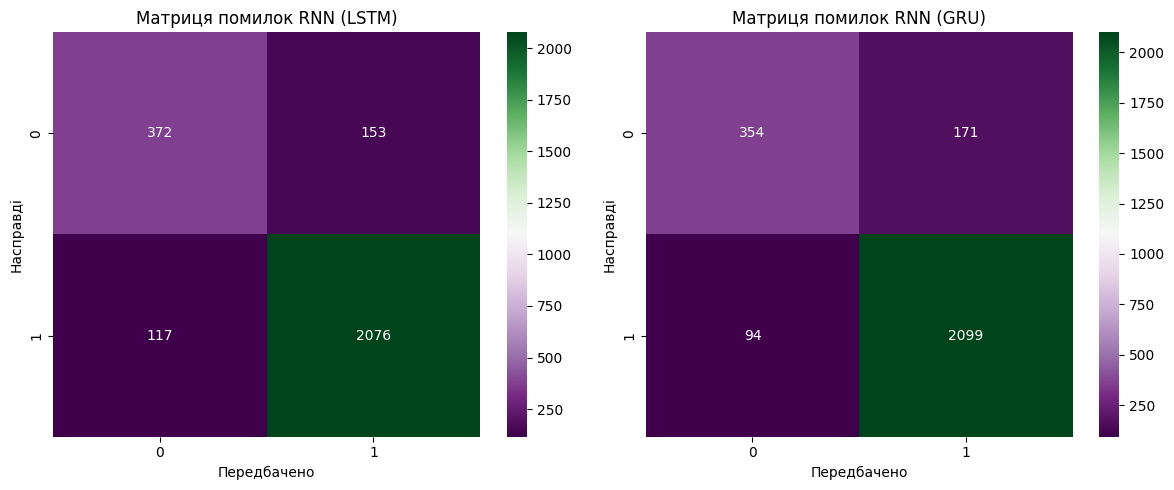

In [31]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_rnn_rec, y_pred_rec_lstm)
sns.heatmap(cm, annot=True, fmt='d', cmap='PRGn')
plt.xlabel('Передбачено')
plt.ylabel('Насправді')
plt.title('Матриця помилок RNN (LSTM)');

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_rnn_rec, y_pred_rec_gru)
sns.heatmap(cm, annot=True, fmt='d', cmap='PRGn')
plt.xlabel('Передбачено')
plt.ylabel('Насправді')
plt.title('Матриця помилок RNN (GRU)');

plt.tight_layout()
plt.show()

In [32]:
print(f'LSTM MAE: {mean_absolute_error(y_rnn_rat, y_prob_rate_lstm):.2f}'
      f'\nLSTM R2: {r2_score(y_rnn_rat, y_prob_rate_lstm):.2f}')

LSTM MAE: 0.57
LSTM R2: 0.59


In [33]:
print(f'GRU MAE: {mean_absolute_error(y_rnn_rat, y_prob_rate_gru):.2f}'
      f'\nGRU R2: {r2_score(y_rnn_rat, y_prob_rate_gru):.2f}')

GRU MAE: 0.54
GRU R2: 0.61


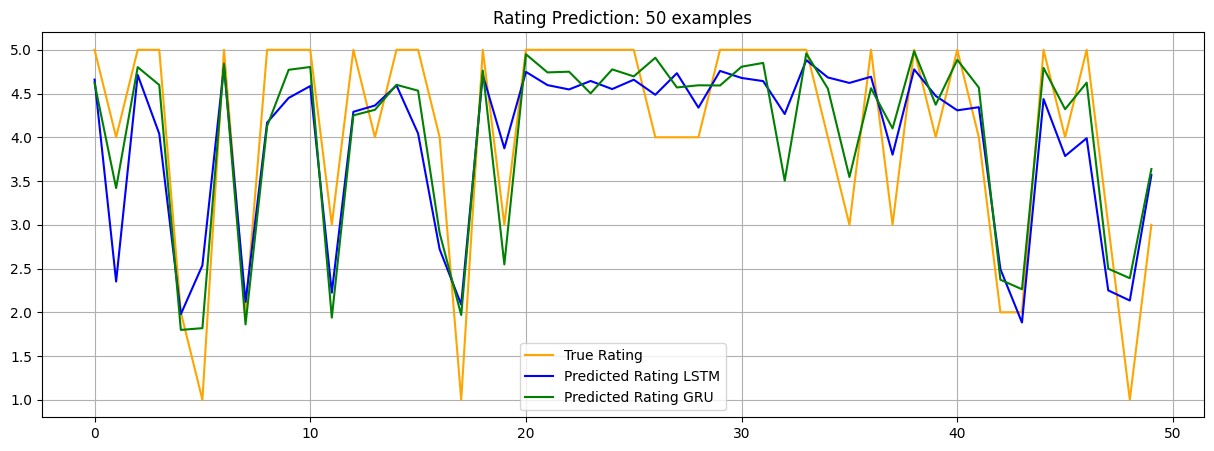

In [34]:
n=50
plt.figure(figsize=(15, 5))
plt.plot(y_rnn_rat[:n], label='True Rating', color='orange')
plt.plot(y_prob_rate_lstm[:n], label='Predicted Rating LSTM', color='blue')
plt.plot(y_prob_rate_gru[:n], label='Predicted Rating GRU', color='green')
plt.title(f'Rating Prediction: {n} examples')
plt.grid()
plt.legend()
plt.show()

Маємо проміжний підсумок.  
Найкраще з визначенням обох параметрів, рейтингу та рекомендацій впоралась модель RNN GRU.  
Але, хоча вона показала беззаперечно кращі результати у визначенні рейтингу (MAE 0.53), вона ділить перше місце по визначенням рекомендації з LSTM.  
Тут кожна з них має свій підхід.  
LSTM краще знаходить негативні рекомендації, GRU - позитивні.

In [35]:
data = {
    'Модель': ['Logistic Regression (BOW)', 'RandomForestClassifier (BOW)',
               'Linear Regression (BOW)', 'RandomForestRegressor (BOW)',
               'RNN (LSTM)', 'RNN (GRU)'],
    'Accuracy': [0.88, 0.85, None, None, 0.90, 0.90],
    'MAE': [None, None, 0.62, 0.63, 0.56, 0.53]
}

df = pd.DataFrame(data)
df

,Модель,Accuracy,MAE
0,Logistic Regression (BOW),0.88,NaN
1,RandomForestClassifier (BOW),0.85,NaN
2,Linear Regression (BOW),NaN,0.62
3,RandomForestRegressor (BOW),NaN,0.63
4,RNN (LSTM),0.90,0.56
5,RNN (GRU),0.90,0.53


# No Review models

In [36]:
val_nr_rec = pd.read_csv('train_test_val/val/val_rec_nr.csv')
val_nr_rat = pd.read_csv('train_test_val/val/val_rat_nr.csv')

In [37]:
X_rat_nr = val_nr_rat.drop('Rating', axis=1)
X_rec_nr = val_nr_rec.drop('Recomendation', axis=1)

In [38]:
y_rat_nr = val_nr_rat['Rating']
y_rec_nr = val_nr_rec['Recomendation']

In [39]:
model_rec_nr = joblib.load('models/no_review/model_nr_rec.joblib')
model_rat_nr = joblib.load('models/no_review/model_nr_rat.joblib')

In [40]:
y_pred_rec_nr = model_rec_nr.predict(X_rec_nr)

In [41]:
train_nr = pd.read_csv('train_test_val/train/train_rec_nr.csv')

In [42]:
X_tr_nr = train_nr.drop('Recomendation', axis=1)
y_tr_nr = train_nr['Recomendation']

In [43]:
print(model_rec_nr.score(X_tr_nr, y_tr_nr))
print(model_rec_nr.score(X_rec_nr, y_rec_nr))

0.7983231361885339
0.7976513098464318


Оскільки на тренувальному та тестовому датасеті значення майже однакові, перенавчання немає.

In [44]:
y_pred_rat_nr = model_rat_nr.predict(X_rat_nr)

In [45]:
print('DecisionTreeClassifier\n')
print(classification_report(y_rec_nr, y_pred_rec_nr))

DecisionTreeClassifier

              precision    recall  f1-score   support

           0       0.22      0.30      0.26       509
           1       0.83      0.77      0.80      2307

    accuracy                           0.68      2816
   macro avg       0.53      0.53      0.53      2816
weighted avg       0.72      0.68      0.70      2816



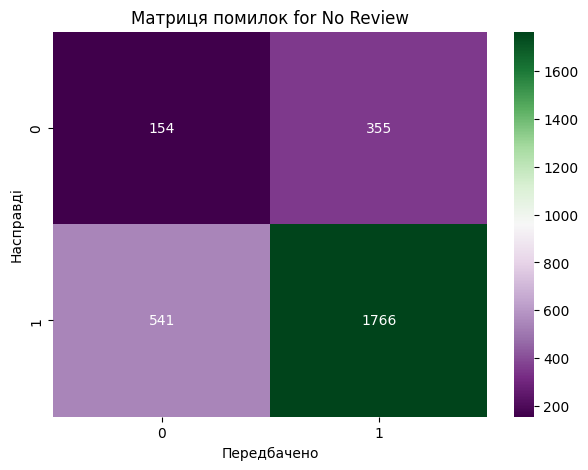

In [46]:
plt.figure(figsize=(7, 5))

cm = confusion_matrix(y_rec_nr, y_pred_rec_nr)
sns.heatmap(cm, annot=True, fmt='d', cmap='PRGn')
plt.xlabel('Передбачено')
plt.ylabel('Насправді')
plt.title('Матриця помилок for No Review');

In [47]:
print(f'Linear Regression MAE: {mean_absolute_error(y_rat_nr, y_pred_rat_nr):.2f}'
      f'\nLinear Regression R2: {r2_score(y_rat_nr, y_pred_rat_nr):.2f}')

Linear Regression MAE: 0.89
Linear Regression R2: 0.01


Як і було зазначено в EDA кореляції між нашими таргетами та іншими ознаками майже немає,  
тому і результати в нас які вже є.